# Enclave Inference — Gemma 3 — Model Owner

| Actor | Email | Role |
|-------|-------|------|
| **Enclave** | `ENCLAVE_EMAIL` | Trusted execution environment |
| **Model owner** | (this notebook) | Owns the Gemma 3 model (weights + inference engine) |
| **Benchmark owner** | (separate notebook) | Owns the private benchmark **and submits the inference job** |

**The setting.** These clients connect to an [enclave](https://github.com/OpenMined/PySyft/tree/dev/packages/syft-enclave) — a sealed environment that runs code on data nobody can see. There are two data owners: the **model owner** (this notebook), who keeps the model private, and the **benchmark owner** (other notebook), who keeps the benchmark private. Both upload their assets into the enclave, and nothing runs on them unless **both owners approve the exact code** first.

The model owner keeps two things private: the model weights, and part of the inference code. That code is a single file with private parts (the model architecture) and public parts (the rest).

First the model owner uploads the private model and submits a job that proves the inference code does not steal any data when it runs, using [syft-restrict](https://github.com/OpenMined/PySyft/tree/dev/packages/syft-restrict). Then the benchmark owner submits a job that runs the model on their benchmark.

## Setup

In [ ]:
!uv pip install -Uq kagglehub==1.0.2 "git+https://github.com/OpenMined/PySyft.git@enclave-mvp#subdirectory=packages/syft-enclave"

In [ ]:
!wget -nc https://raw.githubusercontent.com/OpenMined/PySyft/refs/heads/dev/notebooks/enclave/gemma/colab/gemma_inference_restrict.py

In [ ]:
import os
import random
import shutil
import tempfile
from pathlib import Path


from syft_enclaves import login_do
from gemma_inference_restrict import MODEL_CONFIGS

# ─── Choose model size here ─────────────────────────────────────────────────
MODEL_SIZE = "270m"  # Options: "270m", "1b", "4b", "12b", "27b"
# ───────────────────────────────────────────────────────────────────────────

MODEL_CFG = MODEL_CONFIGS[MODEL_SIZE]
KAGGLE_HANDLE = MODEL_CFG["kaggle_handle"]
CKPT_SUBDIR = MODEL_CFG["ckpt_subdir"]

print(f"Model size   : {MODEL_SIZE}")
print(f"Kaggle handle: {KAGGLE_HANDLE}")
print(f"Checkpoint   : {CKPT_SUBDIR}")

In [ ]:
ENCLAVE_EMAIL         = "test.enclave@gmail.com"
BENCHMARK_OWNER_EMAIL = "test.benchmark.owner@gmail.com"

print(f"  Enclave   : {ENCLAVE_EMAIL}\n  Benchmark : {BENCHMARK_OWNER_EMAIL}")

## Step 0 — Log in as Model Owner

We log in to the enclave. This client lets us upload data and approve jobs in the enclave.

In [ ]:
# Debug enclaves (start-debug / tf-apply-dev) run with encryption off — use encryption=False there.
model_owner = login_do(encryption=True)
print(f"  Model owner : {model_owner.email}")

In [ ]:
# # Optionally to clear state
# model_owner._manager.delete_syftbox()
# model_owner._manager.peer_manager.write_own_version()

### Launch the enclave

## Step 1 — Peer with the Enclave

To make requests to the enclave, we first need to peer with it.

In [ ]:
model_owner.add_peer(ENCLAVE_EMAIL)
print(f"  Model owner peered with enclave ({ENCLAVE_EMAIL})")

### Step 1.1 — Wait for the Benchmark Owner peer request, then approve

The Benchmark Owner notebook adds you as a peer. Re-run the cell below until you see their request appear, then approve.

In [ ]:
model_owner.peers

In [ ]:
model_owner.approve_peer_request(BENCHMARK_OWNER_EMAIL, peer_must_exist=False)
print("  Benchmark owner peer approved")

### Step 1.2 — Attest the enclave's identity

Here we validate the attestation report. It confirms the standard enclave properties — the hashes of the BIOS, operating system, system processes, and applications — and signs those hashes with a private key that only the enclave holds. It also confirms the exact PySyft version and configuration. This ties the approvals of both the model owner and the benchmark owner to the exact code, inputs, parameters, and output policy. PySyft handles all of this automatically. This signed hash could only be faked if the hardware provider and the model owner colluded.

In [ ]:
# Wait for enclave to accept peer request
model_owner.attest_peer(ENCLAVE_EMAIL)

## Step 2 — Get the Gemma 3 model

We mount the Gemma 3 model. In a real scenario this would come from the model owner's private data.

The Notebooks assumes, that gemma-3 model is present in your Google Drive, kindly upload the model to your Google Drive. You could use the kaggle API to download the model from Kaggle and upload it to your Google Drive. The command to download the model from Kaggle is below.

After Downloading the model locally , you could upload the model folder from `~/.cache/kagglehub/models/google/gemma-3/flax/{MODEL_SIZE_FOLDER}` to Google drive


In [ ]:
# import kagglehub

# # Authenticate to Kaggle (one-time). You must also accept the Gemma license once at
# # https://www.kaggle.com/models/google/gemma-3
# kagglehub.login()

# print(f"Downloading: {KAGGLE_HANDLE}")
# weights_dir = Path(kagglehub.model_download(KAGGLE_HANDLE))
# print(f"Weights directory: {weights_dir}")
# print(f"Contents: {os.listdir(weights_dir)}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

GEMMA_3_WEIGHTS_DIR = Path(f"~/.cache/kagglehub/models/google/gemma-3/flax").expanduser().absolute()
GEMMA_3_WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
# copy drive weights to cache if not already present
!cp -R /content/drive/MyDrive/gemma-3-270m-it ~/.cache/kagglehub/models/google/gemma-3/flax

weights_dir = Path(f"~/.cache/kagglehub/models/{KAGGLE_HANDLE}/1").expanduser().absolute()

## Step 3 — Prepare the files for upload

We bundle what goes into the enclave. The private side is the inference code, the checkpoint weights, and the tokenizer. The public (mock) side is just a model card describing the model.

In [ ]:
# Build Model owner's private dataset directory: inference code + weights + tokenizer
INFERENCE_MODULE = Path("gemma_inference_restrict.py").resolve()
assert INFERENCE_MODULE.exists(), f"Missing {INFERENCE_MODULE}"


def create_model_private_dir() -> Path:
    """Bundle inference code + weights into a single directory."""
    

    # Copy inference module (uploaded under its canonical name)
    shutil.copy2(INFERENCE_MODULE, weights_dir / "gemma_inference.py")

    return weights_dir


def create_model_mock_file() -> Path:
    """Public model card — visible to the benchmark owner."""
    tmp = Path(tempfile.mkdtemp()) / f"model-mock-{random.randint(1, 1_000_000)}"
    tmp.mkdir(parents=True, exist_ok=True)
    p = tmp / "model_card.txt"
    p.write_text("\n".join([
        f"Gemma 3 {MODEL_SIZE.upper()}-IT: A {MODEL_SIZE} parameter instruction-tuned language model.",
        f"{'=' * (len(MODEL_SIZE) + 12)}",
        "License: Gemma Terms of Use",
        "Intended use: Research and evaluation purposes",
        "",
        "Usage:",
        "  import gemma_inference as gemma",
        f'  model, tokenizer, params = gemma.setup_model("{MODEL_SIZE}", weights_dir)',
        '  response, stats = gemma.generate(model, params, tokenizer, "Your prompt here")',
        "",
    ]))
    return p

In [ ]:
model_private_dir = create_model_private_dir()
model_mock = create_model_mock_file()

print(f"Private dir contents:")
for item in sorted(model_private_dir.rglob("*")):
    if item.is_file():
        size_mb = item.stat().st_size / (1024 * 1024)
        print(f"  {item.relative_to(model_private_dir)}  ({size_mb:.1f} MB)")

## Step 4 — Upload the private model

We upload the private model into the enclave. The inference code comes from [`gemma_inference_restrict.py`](https://github.com/OpenMined/PySyft/blob/dev/notebooks/enclave/gemma/colab/gemma_inference_restrict.py). It is already annotated with private and public regions using comments; when we run syft-restrict on it, it validates the private regions. No one can access this model — it can only be used in jobs that both owners approve.

In [ ]:
model_owner.create_dataset(
    name="gemma3_model",
    mock_path=model_mock,
    private_path=model_private_dir,
    summary=f"Gemma 3 {MODEL_SIZE.upper()}-IT — instruction-tuned language model for safety evaluation",
    users=[BENCHMARK_OWNER_EMAIL, ENCLAVE_EMAIL],
)
model_owner.share_private_dataset("gemma3_model", ENCLAVE_EMAIL)
print("  Model owner uploaded 'gemma3_model'")

## Step 5 — Run `syft-restrict` on the inference code

We submit a job that runs [syft-restrict](https://github.com/OpenMined/PySyft/tree/dev/packages/syft-restrict) on the inference code. syft-restrict does two things:

1. It creates a readable copy of the code with the private regions hidden.
2. It analyses the code and makes sure the private code only uses non-dynamic Python that cannot leak the benchmark.

In [ ]:
# The exact JAX/Flax leaves the private region may call; everything else is rejected.
ALLOW_FUNCTIONS = [
    "jax.numpy.einsum", "jax.numpy.mean", "jax.numpy.square", "jax.numpy.arange",
    "jax.numpy.sin", "jax.numpy.cos", "jax.numpy.concatenate", "jax.numpy.tril",
    "jax.numpy.triu", "jax.numpy.ones", "jax.numpy.where", "jax.numpy.repeat",
    "jax.numpy.sqrt", "jax.numpy.transpose", "jax.numpy.array", "jax.numpy.float32",
    "jax.numpy.bool_", "jax.lax.rsqrt", "jax.nn.softmax", "jax.nn.gelu",
    "flax.linen.Module", "jax.lax", "jax.nn",
]
ALLOW_OPERATORS = ["arithmetic", "indexing", "comparison"]

RESTRICT_JOB_NAME = "restrict_engine_review"
RESTRICT_JOB_CODE = f'''
import json
import os

import syft_client as sc
import syft_restrict as restrict

files = sc.resolve_dataset_files_path("gemma3_model", owner_email="{model_owner.email}")
src_path = [p for p in files if p.name == "gemma_inference.py"][0]

os.makedirs("outputs", exist_ok=True)
result = restrict.run(
    src_path,
    allow_functions={ALLOW_FUNCTIONS},
    allow_operators={ALLOW_OPERATORS},
    out="outputs/gemma_inference.obfuscated.py",
    strict=False,
)

if not result.ok:
    for v in result.violations:
        print(f"  line {{v.line}} [{{v.code}}] {{v.message}}")
    raise SystemExit(1)

with open("outputs/gemma_inference.certificate.json", "w") as f:
    json.dump(result.certificate, f, indent=2)

print(f"RESTRICT PASSED — {{result.certificate['n_calls_checked']}} calls checked")
print(f"  policy id     : {{result.certificate['policy_id']}}")
print(f"  source sha256 : {{result.certificate['source_sha256']}}")
'''


def create_code_file(code: str) -> str:
    tmp = Path(tempfile.mkdtemp()) / f"job-{random.randint(1, 1_000_000)}"
    tmp.mkdir(parents=True, exist_ok=True)
    p = tmp / "main.py"
    p.write_text(code)
    return str(p)

In [ ]:
model_owner.submit_python_job(
    ENCLAVE_EMAIL,
    create_code_file(RESTRICT_JOB_CODE),
    RESTRICT_JOB_NAME,
    datasets={
        model_owner.email: ["gemma3_model"],
        BENCHMARK_OWNER_EMAIL: [],  # no data — recipient of the verdict only
    },
    share_results_with_do=True,
    dependencies=["syft-restrict"],
)
print(f"  Job '{RESTRICT_JOB_NAME}' submitted to the enclave ({ENCLAVE_EMAIL})")

### Step 5.1 — Approve the job

We approve the job. Every job that runs must be approved by both parties.

In [ ]:
restrict_job = next((j for j in model_owner.jobs if j.name == RESTRICT_JOB_NAME), None)

if restrict_job is None:
    print(f" 🟠  Job '{RESTRICT_JOB_NAME}' not visible yet — the enclave is still distributing it. Wait a moment and re-run this cell.")
else:
    print(f" ✅ Model owner sees '{RESTRICT_JOB_NAME}'  status={restrict_job.status}")

In [ ]:
restrict_job

In [ ]:
model_owner.approve_job(restrict_job)
print("  Model owner approved")

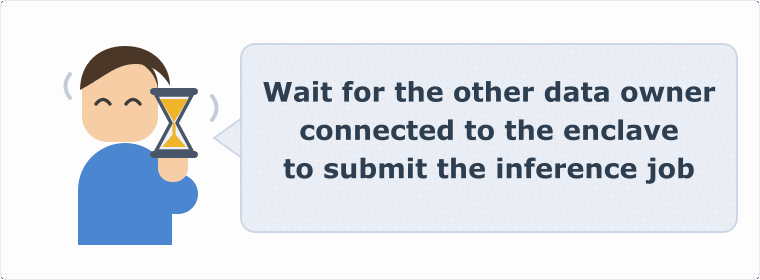


## Step 6 — Approve the final inference job

Now we wait for the benchmark owner to submit the final job that runs the model on the private benchmark. We carefully inspect the code to make sure it only does that, then we approve. The final result is shared with the benchmark owner.

In [ ]:
JOB_NAME = "safety_eval_job"
model_owner_job = next((j for j in model_owner.jobs if j.name == JOB_NAME), None)

if model_owner_job is None:
    print(f" 🟠 Job '{JOB_NAME}' not visible yet — the enclave is still distributing it. Wait a moment and re-run this cell.")
else:
    print(f" ✅ Model owner sees '{JOB_NAME}'  status={model_owner_job.status}")

In [ ]:
model_owner_job

In [ ]:
model_owner.approve_job(model_owner_job)
print("  Model owner approved")